In [199]:
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [200]:
file="breastmnist.npz"

In [201]:
data=np.load(file)
data

NpzFile 'breastmnist.npz' with keys: train_images, val_images, test_images, train_labels, val_labels...

In [202]:
x_train,y_train=data['train_images'],data['train_labels']
val_x,val_y=data['val_images'],data['val_labels']
x_test,y_test=data['test_images'],data['test_labels']

In [203]:
x_train = x_train.reshape(-1,28,28,1)
x_val   = val_x.reshape(-1,28,28,1)
x_test  = x_test.reshape(-1,28,28,1)

In [204]:
test_g=ImageDataGenerator(rescale=1./255)
train_g=ImageDataGenerator(zoom_range=0.10,rescale=1./255)
val_g=ImageDataGenerator(rescale=1./255)
train=train_g.flow(x_train,y_train,batch_size=50)
test=test_g.flow(x_test,y_test,batch_size=50)
val=val_g.flow(x_val,val_y,batch_size=50)

In [205]:
print(x_train.shape)

(546, 28, 28, 1)


In [206]:
print(x_test.shape)

(156, 28, 28, 1)


In [207]:
model=Sequential()
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))
model.add(Conv2D(50,(3,3),activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(300,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [208]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])


In [209]:
history=model.fit(train,validation_data=val,epochs=100)

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7106 - loss: 0.6132 - val_accuracy: 0.7308 - val_loss: 0.5786
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7308 - loss: 0.5770 - val_accuracy: 0.7308 - val_loss: 0.5865
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7308 - loss: 0.5622 - val_accuracy: 0.7308 - val_loss: 0.5647
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7308 - loss: 0.5491 - val_accuracy: 0.7308 - val_loss: 0.5806
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7308 - loss: 0.5428 - val_accuracy: 0.7308 - val_loss: 0.5474
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7308 - loss: 0.5357 - val_accuracy: 0.7308 - val_loss: 0.5372
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7308 - loss: 0.5272 - val_accuracy: 0.7308 - val_loss: 0.5525
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7363 - loss: 0.5411 - val_accuracy: 0.74

In [210]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_33 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 3, 3, 50)       │        28,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 1, 1, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 1, 1, 50)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 300)            │        15,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           301 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,803 (741.42 KB)

 Trainable params: 63,267 (247.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 126,536 (494.29 KB)

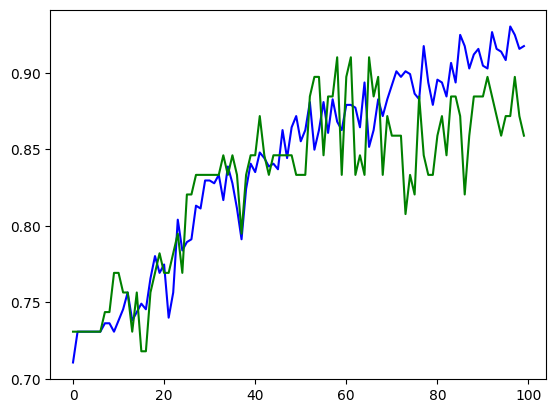

In [211]:
plt.plot(history.history['accuracy'],color='blue',label='accuracy')
plt.plot(history.history['val_accuracy'],color='green',label='val accuracy')